In [2]:
%run shared_imports.py

In [3]:
engine = make_engine("settings.toml")
session = Session(engine)

In [28]:
query = select(Feedback.json, Feedback.datetime).filter(
    Feedback.key_name == 'cargo salvage sold',
    Feedback.datetime >= datetime(2023, 7, 1))

In [32]:
df = pd.read_sql_query(query, session.connection())

In [23]:
def salvage_income(row):
    return {"income": sum([x['credits'] for x in row['data'].values()])}

In [33]:
df = df.join(pd.json_normalize(df.json.map(salvage_income))).drop(['json'], axis=1)
summed = df.resample('D', on='datetime')["income"].sum()
# df['dt'] = pd.to_datetime(df.datetime.dt.year.astype(str) + df.datetime.dt.month.astype(str), format='%Y%m')
# df.drop(['datetime'], inplace=True, axis=1)

In [43]:
summed
summed = summed.resample('D').interpolate()[::7]

In [48]:
summed

datetime
2024-05-18     9000
2024-05-25    17400
2024-06-01    15200
2024-06-08     5800
2024-06-15     9300
2024-06-22     6300
2024-06-29     7900
2024-07-06     4900
2024-07-13    11000
2024-07-20     6400
2024-07-27     6800
2024-08-03     5900
2024-08-10     1400
2024-08-17     9100
2024-08-24     6000
Freq: 7D, Name: income, dtype: int64

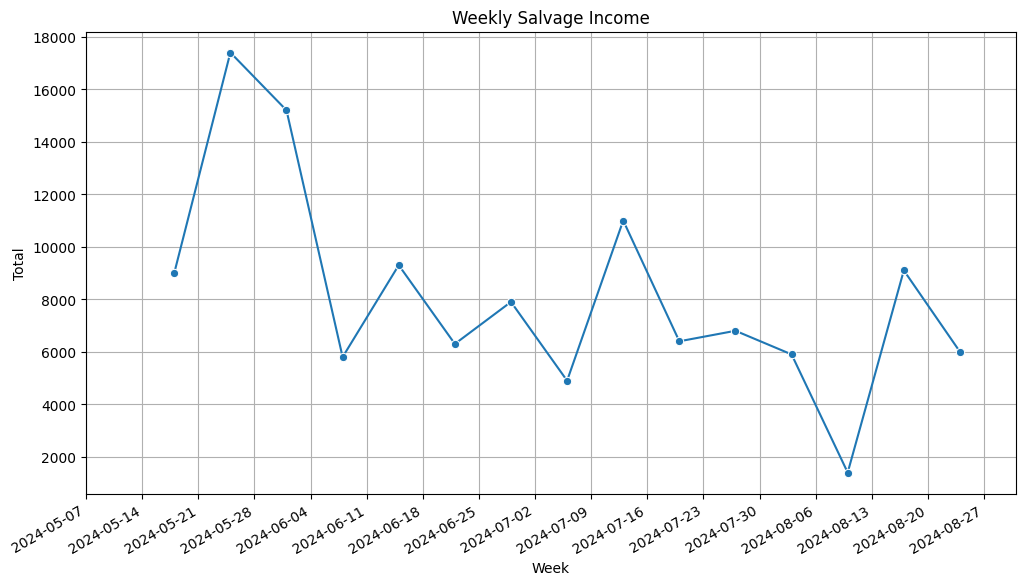

In [57]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
plot = sns.lineplot(
    data=summed,
    marker='o',
    linestyle='solid',
    dashes=False,
)
plot.set(xlim=(date(2024, 5, 7), date(2024, 8, 31)))
plot.set(title='Weekly Salvage Income')
plot.set(xlabel='Week', ylabel='Total')
weeks = mdates.WeekdayLocator(interval=1)
ax.xaxis.set_major_locator(weeks)
ax.xaxis.set_minor_locator(weeks)

for label in ax.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax.grid()

plt.savefig('cargo_salvage_sold.png')